# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Kaka Davi Dharmawan
- **Email:** kakadavidarmawan@gmail.com
- **ID Dicoding:** dapiupiu

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana pengaruh kondisi cuaca *(weathershit)* terhadap rata-rata jumlah penyewaan sepeda per jam?
- **Pertanyaan 2:** Di jam berapa terjadi puncak penyewaan sepeda pada hari kerja *(workingday)* dibandingkan dengan hari libur *(holiday)*?

## Import Semua Packages/Library yang Digunakan

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Data Wrangling

### Gathering Data

#### Load hour_df [hour.csv]

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# cek 5 baris data pertama
hour_df = pd.read_csv('/content/drive/MyDrive/analisis_data_dataset/hour.csv')
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [6]:
# cek jumlah baris dan kolom
hour_df.shape

(17379, 17)

**Insight:**
- Secara sekilas, data menunjukkan informasi waktu (dteday, hr), kondisi lingkungan (temp, hum), dan jumlah pengguna. Kolom instant tampaknya hanya merupakan indeks rekam data dan mungkin tidak akan memberikan nilai analisis yang signifikan.
- Dataset ini memiliki 17.379 baris dan 17 kolom. Jumlah baris yang besar ini menunjukkan bahwa kita memiliki data yang sangat mendalam (granular) karena mencatat penyewaan setiap jam selama kurang lebih 2 tahun. Ini sudah lebih dari cukup untuk menghasilkan analisis tren yang akurat dan kredibel.

### Assessing Data

#### Identifying Data Types and Inaccurate Values Problem

In [7]:
# melihat informasi dataset
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [8]:
# cek statistik deskriptif
hour_df.describe(include='all')

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
unique,NaN,731,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2012-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,8690.0000,NaN,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,NaN,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,NaN,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,NaN,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,NaN,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000


In [9]:
# cek nilai negatif
numeric_df = hour_df.select_dtypes(include=np.number)
display(numeric_df[numeric_df<0])

print(f'Data dengan nilai negatif:\n{numeric_df[numeric_df<0].sum()}')

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17375,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17376,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17377,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Data dengan nilai negatif:
instant       0.0
season        0.0
yr            0.0
mnth          0.0
hr            0.0
holiday       0.0
weekday       0.0
workingday    0.0
weathersit    0.0
temp          0.0
atemp         0.0
hum           0.0
windspeed     0.0
casual        0.0
registered    0.0
cnt           0.0
dtype: float64


In [10]:
# cek jumlah total data yang tidak sama (anomali)
(hour_df['casual'] + hour_df['registered'] != hour_df['cnt']).sum()

np.int64(0)

In [11]:
# cek missing value
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [12]:
# cek duplikasi data
print('Jumlah Duplikasi Data:', hour_df.duplicated().sum())

Jumlah Duplikasi Data: 0


In [13]:
# cek jumlah angka 0 pada kolom hum (tidak mungkin kelembapan udara bernilai 0)
print(f"Jumlah nilai 0 di kolom 'hum': {(hour_df['hum'] == 0).sum()}")

Jumlah nilai 0 di kolom 'hum': 22


In [14]:
# menghitung selisih temp dan atemp
temp_diff = abs(hour_df['temp'] - hour_df['atemp'])

# menampilkan baris yang memiliki selisih lebih dari 0.1 dan 0.2
extreme_temp1 = hour_df[temp_diff > 0.1]
extreme_temp2 = hour_df[temp_diff > 0.2]

# Cek berapa banyak jumlahnya
print(f"Jumlah data dengan perbedaan suhu ekstrem lebih dari 0.1: {len(extreme_temp1)}")
print(f"Jumlah data dengan perbedaan suhu ekstrem lebih dari 0.2: {len(extreme_temp2)}")

Jumlah data dengan perbedaan suhu ekstrem lebih dari 0.1: 248
Jumlah data dengan perbedaan suhu ekstrem lebih dari 0.2: 24


**Steps to Take:**
- **Mengubah Tipe Data:** Mengonversi kolom `dteday` dari tipe `object` menjadi `datetime` agar analisis berbasis waktu dapat dilakukan dengan tepat.
- **Menangani Anomali Data:** Menghapus *(drop)* **22 baris** data yang memiliki nilai kelembapan `(hum)` sebesar **0**, karena nilai tersebut tidak masuk akal secara logis (kemungkinan kesalahan/kerusakan pada sensor).
- **Transformasi Data *(Mapping*):** Mengubah nilai numerik pada kolom `season, mnth,` dan `weathersit` menjadi label teks agar lebih mudah diinterpretasikan dalam tahap visualisasi.
- **Final Validation**: Memastikan tidak ada data yang hilang *(missing values)* atau duplikat setelah proses pembersihan selesai.

**Insight:**
- **Kualitas Data:** Dataset secara umum sangat bersih; tidak ditemukan data yang hilang *(missing values)* maupun data ganda *(duplicated data)*.
- **Integritas Numerik:** Jumlah total penyewaan `(cnt)` sudah konsisten dengan penjumlahan pengguna `casual` dan `registered`
- **Temuan Anomali:** Terdapat ketidaksesuaian tipe data pada kolom dteday dan adanya **22 baris** dengan nilai kelembapan **0** `(hum)` yang perlu ditangani.
- **Karakteristik Outlier:** Ditemukan nilai penyewaan maksimal hingga **977 per jam**. Setelah dianalisis, ini dianggap sebagai natural outlier yang merepresentasikan lonjakan permintaan pada jam-jam sibuk, sehingga data ini akan tetap dipertahankan untuk menjaga keaslian pola tren.

### Cleaning Data

#### Fixing Data Types and Anomalies Problem

In [15]:
# ubah tipe data dteday ke datetime
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

In [16]:
# cek ulang info dataset
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

In [17]:
# hapus baris bernilai 0 di kolom 'hum'
hour_df.drop(hour_df[hour_df['hum'] == 0].index, inplace=True)

In [18]:
# cek ulang nilai 0 di kolom 'hum'
print(f"Jumlah nilai 0 di kolom 'hum': {(hour_df['hum'] == 0).sum()}")

Jumlah nilai 0 di kolom 'hum': 0


In [19]:
# cek ulang jumlah baris setelah optimalisasi kolom 'hum'
hour_df.shape

(17357, 17)

In [20]:
# mengubah kolom menjadi kategorikal agar mudah divisualisasi
# mapping data untuk kolom 'season'
hour_df['season'] = hour_df['season'].map({
    1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'
})

# mapping data untuk kolom 'weathersit'
hour_df['weathersit'] = hour_df['weathersit'].map({
    1: 'Clear',
    2: 'Misty',
    3: 'Light Snow/Rain',
    4: 'Heavy Rain/Ice Pallets'
})

# mapping data untuk kolom 'mnth'
hour_df['mnth'] = hour_df['mnth'].map({
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
})

# mapping data untuk kolom 'workingday'
hour_df['workingday'] = hour_df['workingday'].map({
    0: 'Weekend/Holiday',
    1: 'Working Day'
})

hour_df['holiday'] = hour_df['holiday'].map({
    0: 'Not Holiday',
    1: 'Holiday'
})

# tampilkan 5 baris pertama
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,0,Jan,0,Not Holiday,6,Weekend/Holiday,Clear,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,Spring,0,Jan,1,Not Holiday,6,Weekend/Holiday,Clear,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,Spring,0,Jan,2,Not Holiday,6,Weekend/Holiday,Clear,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,Spring,0,Jan,3,Not Holiday,6,Weekend/Holiday,Clear,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,Spring,0,Jan,4,Not Holiday,6,Weekend/Holiday,Clear,0.24,0.2879,0.75,0.0,0,1,1


In [21]:
# cek ulang kembali missing value (mengantisipasi ada nilai yang terlewat diubah) dan duplikasi data
print(f'Jumlah missing value:\n{hour_df.isna().sum()}')
print()
print(f'Jumlah duplikasi data: {hour_df.duplicated().sum()}')

Jumlah missing value:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Jumlah duplikasi data: 0


**Insight:**
- **Pembersihan Anomali:** Sebanyak **22 baris** data dengan nilai kelembapan (`hum`) sebesar **0** telah dihapus. Hal ini memastikan bahwa analisis pengaruh cuaca nantinya tidak terganggu oleh data yang tidak masuk akal (kesalahan sensor/kelembapan **0%**).
- **Konsistensi Tipe Data:** Kolom `dteday` kini telah bertipe `datetime`, yang memungkinkan kita untuk mengekstraksi informasi waktu yang lebih detail (seperti jam, hari, atau bulan) dengan akurat.
- **Kemudahan Interpretasi:** Melalui proses mapping pada kolom season, mnth, dan weathersit, data kini jauh lebih mudah dibaca. Contohnya, angka `'1'` pada cuaca kini terbaca sebagai `'Clear'`, sehingga mengurangi risiko kesalahan interpretasi selama tahap EDA dan visualisasi.
- **Integritas Data:** Setelah pembersihan, dataset akhir terdiri dari **17.357 baris**. Tidak ada data yang hilang (*missing values*) maupun duplikasi, sehingga data siap untuk dianalisis lebih lanjut.
---
**Insight Tambahan:**

Outlier pada kolom `cnt` (**977 penyewaan/jam**) dipertahankan karena merupakan *natural outlier*. Menghapus data ini akan menghilangkan informasi penting mengenai perilaku pengguna pada jam-jam puncak (*rush hour*) atau saat ada acara khusus.

## Exploratory Data Analysis (EDA)

### Explore Weather and Rental Performance

In [22]:
# pengelompokan berdasarkan kolom 'weathersit' dan hitung statistik
weather_rent_df = hour_df.groupby(by="weathersit").agg({
    "cnt": ["mean", "max", "min", "std"]
})

weather_rent_df

cnt                     
                              mean  max min         std
weathersit                                             
Clear                   204.869272  977   1  189.487773
Heavy Rain/Ice Pallets   74.333333  164  23   77.925178
Light Snow/Rain         112.832738  891   1  134.298860
Misty                   175.210700  957   1  165.452009

### Explore Hour (Workingday vs Holiday)

In [23]:
# pengelompokan berdasarkan workingday (yes/no) dan hour (jam)
hourly_rent_df = hour_df.groupby(by=["workingday", "hr"]).agg({
    "cnt": ["sum", "max", "min", "mean"]
}).reset_index()

# tampilkan data 24 jam pertama, urutkan berdasarkan rata-rata cnt
hourly_rent_df.head(24).sort_values(by=('cnt', 'sum'), ascending=False)

workingday  hr    cnt                     
                           sum  max min        mean
13  Weekend/Holiday  13  86101  760  30  372.731602
12  Weekend/Holiday  12  84606  776  32  366.259740
14  Weekend/Holiday  14  84233  750  23  364.645022
15  Weekend/Holiday  15  82886  750   7  358.813853
16  Weekend/Holiday  16  81480  783  11  352.727273
17  Weekend/Holiday  17  74740  731  15  323.549784
11  Weekend/Holiday  11  72838  663  27  315.316017
18  Weekend/Holiday  18  64643  676  23  281.056522
10  Weekend/Holiday  10  59115  539  12  255.909091
19  Weekend/Holiday  19  53285  554  11  231.673913
20  Weekend/Holiday  20  40190  551  11  174.739130
9   Weekend/Holiday   9  39645  397  14  171.623377
21  Weekend/Holiday  21  32674  584   7  142.060870
22  Weekend/Holiday  22  26694  502   9  116.060870
8   Weekend/Holiday   8  24406  597   5  105.653680
0   Weekend/Holiday   0  20884  249   6   90.800000
23  Weekend/Holiday  23  19764  239   2   85.930435
1   Weekend/Holiday   1  15987  168   4   69.508696
2   Weekend/Holiday   2  12123  132   2   53.171053
7   Weekend/Holiday   7  10027  387   1   43.406926
3   Weekend/Holiday   3   5851   79   2   25.775330
6   Weekend/Holiday   6   4292  133   1   18.742358
5   Weekend/Holiday   5   1929   55   1    8.689189
4   Weekend/Holiday   4   1876   28   1    8.264317

In [24]:
# mengambil data khusus hari kerja (workingday = 1)
working_day_df = hourly_rent_df[hourly_rent_df['workingday'] == "Working Day"]

working_day_df.sort_values(by=("cnt", "sum"), ascending=False).head(10)

workingday  hr     cnt                     
                        sum  max min        mean
41  Working Day  17  262009  976  26  526.122490
42  Working Day  18  245047  977  26  493.052314
32  Working Day   8  236551  839  31  477.880808
43  Working Day  19  173448  743  18  348.989940
40  Working Day  16  146247  634  13  293.668675
31  Working Day   7  144107  596  18  291.125253
44  Working Day  20  124322  567  23  250.144869
33  Working Day   9  119769  426  23  241.957576
39  Working Day  15  100249  601  13  201.708249
36  Working Day  12   99774  471   3  201.157258

In [25]:
# pengelompokan berdasarkan hari libur (holiday)
holiday_rent_df = hour_df.groupby(by="holiday").agg({
    'cnt':['sum', 'max', 'min', 'mean']
})

holiday_rent_df

cnt                     
                 sum  max min        mean
holiday                                  
Holiday        78435  712   1  156.870000
Not Holiday  3213621  977   1  190.640149

### Explore Sum Based on Month

In [26]:
# pengelompokan berdasarkan bulan dengan penjualan terbanyak
month_rent_df = hour_df.groupby(by="mnth").agg({
    "cnt": ["mean", "sum"]
})

month_rent_df.sort_values(by=[("cnt", "sum")], ascending=False)

cnt        
            mean     sum
mnth                    
Aug   238.097627  351194
Jun   240.515278  346342
Sep   240.773138  345991
Jul   231.819892  344948
May   222.907258  331686
Oct   222.158511  322352
Apr   187.260960  269094
Nov   177.335421  254831
Mar   157.337698  228297
Dec   142.303439  211036
Feb   112.865026  151352
Jan    94.424773  134933

**Insight:**

**Pengaruh Kondisi Cuaca terhadap Performa Penyewaan**
- **(Temuan Utama):** Terdapat korelasi positif yang signifikan antara kondisi cuaca cerah dengan minat pengguna. Rata-rata penyewaan tertinggi terjadi pada kondisi Clear/Cerah dengan angka **204.87 unit/jam**.
- **(Analisis Komparatif):** Terjadi penurunan permintaan yang sangat drastis ketika cuaca memburuk (kategori Light Snow/Rain), di mana rata-rata penyewaan turun hingga di bawah **100 unit/jam**.
- **(Insight Bisnis):** Stabilitas pendapatan perusahaan sangat bergantung pada kondisi cuaca. Hal ini menunjukkan pentingnya strategi operasional tambahan pada saat musim dengan cuaca ekstrem.

---

**Pola Perilaku Pengguna Berdasarkan Waktu dan Tipe Hari**

- **(Hari Kerja / Working Day):** Mengikuti pola "Double Peak" (M-Shaped). Puncak aktivitas terjadi pada pukul **08:00 (berangkat kerja)** dan pukul **17:00 - 18:00 (pulang kerja)**. Ini membuktikan bahwa pada hari kerja, sepeda digunakan sebagai moda transportasi utama/utilitas.
- **(Hari Libur/Akhir Pekan / Weekend/Holiday):** Mengikuti pola "Single Peak" (Bell Curve). Aktivitas meningkat secara bertahap sejak pagi dan mencapai puncaknya pada pukul **13:00** dengan rata-rata **372.73 unit/jam**. Pola ini mengindikasikan penggunaan sepeda untuk tujuan rekreasi.

- **Tren Musiman (Analisis Bulanan - Periode Puncak):** Bulan Agustus tercatat sebagai periode paling sibuk sepanjang tahun dengan akumulasi penyewaan tertinggi (rata-rata **238.10 unit/jam**).
- **Tren Musiman (Analisis Bulanan - Tren Tahunan):** Terdapat pertumbuhan penyewaan yang konsisten seiring transisi musim dari dingin ke panas (Januari hingga Agustus), sebelum kemudian mengalami penurunan kembali menjelang akhir tahun.

---

- **Kualitas Data dan Penanganan Anomali (Natural Outliers):** Ditemukan nilai maksimal hingga **977 penyewaan/jam**. Data ini dipertahankan karena merupakan representasi akurat dari lonjakan permintaan (peak demand) pada kondisi cuaca dan waktu yang ideal.

- **Kualitas Data dan Penanganan Anomali (Pembersihan Data):** Sebanyak **22 baris** dengan data kelembapan **0%** (yang tidak masuk akal secara logis) telah dihapus untuk memastikan hasil analisis cuaca tetap objektif dan akurat.

## Visualization & Explanatory Analysis

In [27]:
# set style global
sns.set_style("whitegrid")
# warna yang nyaman dimata
colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

### Pertanyaan 1: Bagaimana pengaruh kondisi cuaca (*weathershit*) terhadap rata-rata jumlah penyewaan sepeda per jam?

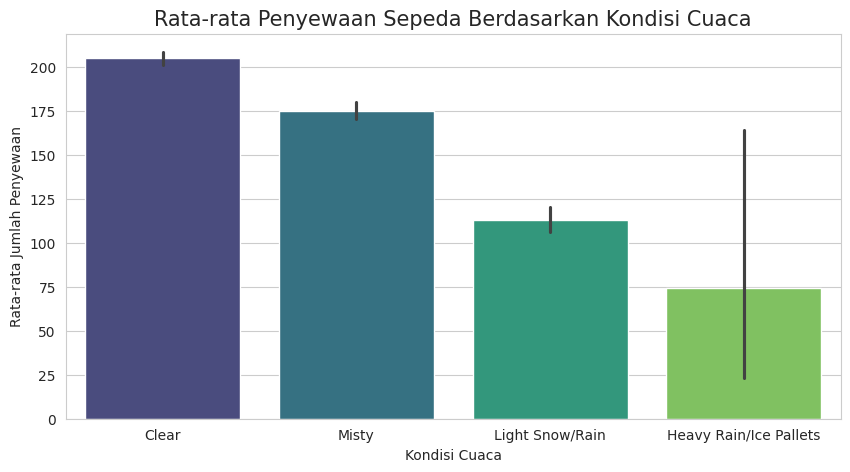

In [28]:
plt.figure(figsize=(10, 5))

# bar chart untuk rata-rata penyewaan berdasarkan cuaca
sns.barplot(
    x="weathersit",
    y="cnt",
    data=hour_df,
    palette="viridis",
    hue="weathersit",
    legend=False
)

plt.title("Rata-rata Penyewaan Sepeda Berdasarkan Kondisi Cuaca", loc="center", fontsize=15)
plt.ylabel("Rata-rata Jumlah Penyewaan")
plt.xlabel("Kondisi Cuaca")
plt.show()

### Pertanyaan 2: Di jam berapa terjadi puncak penyewaan sepeda pada hari kerja (workingday) dibandingkan dengan hari libur (holiday)?

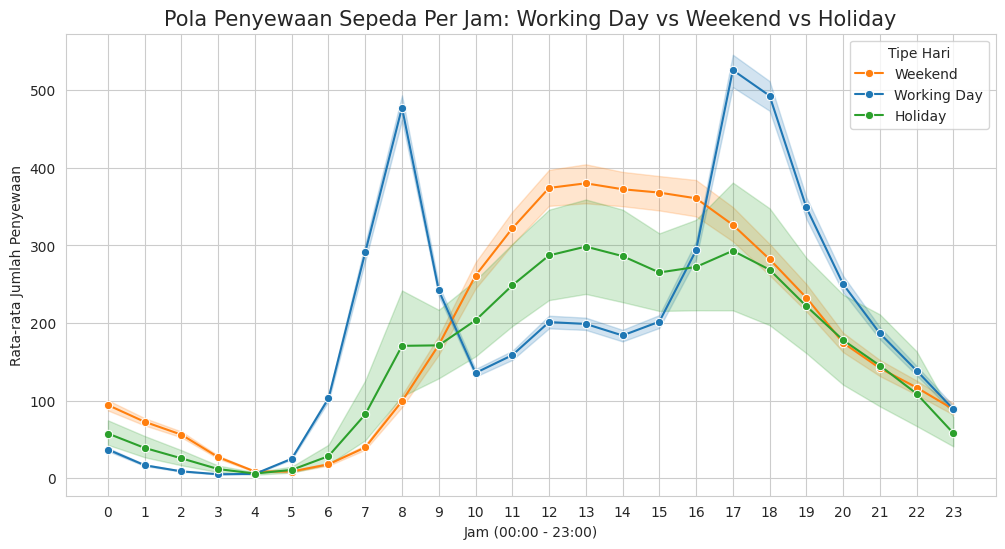

In [29]:
# menyiapkan kolom day_type (jika belum ada)
def get_day_type(row):
    if row['holiday'] == 'Holiday':
        return 'Holiday'
    elif row['workingday'] == 'Working Day':
        return 'Working Day'
    else:
        return 'Weekend'

hour_df['day_type'] = hour_df.apply(get_day_type, axis=1)

# membuat visualisasi tren per jam
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=hour_df,
    x="hr",
    y="cnt",
    hue="day_type",
    marker="o",
    palette={"Working Day": "#1f77b4", "Weekend": "#ff7f0e", "Holiday": "#2ca02c"}
)

plt.title("Pola Penyewaan Sepeda Per Jam: Working Day vs Weekend vs Holiday", fontsize=15)
plt.xlabel("Jam (00:00 - 23:00)")
plt.ylabel("Rata-rata Jumlah Penyewaan")
plt.xticks(range(0, 24))
plt.legend(title="Tipe Hari")
plt.show()

**Insight Grafik Pertanyaan 1:**

- **Dominasi Cuaca Cerah:** Kondisi "`Clear`" secara mutlak menjadi pendorong performa tertinggi dengan rata-rata di atas **200 penyewaan/jam**. Ini adalah **"zona nyaman"** operasional bisnis.

- **Gradasi Penurunan yang Signifikan:** Terlihat penurunan bertahap yang konsisten. Dari `Clear` ke `Misty` turun sekitar **12%**, namun saat masuk ke `Light Snow/Rain`, angka penyewaan anjlok hampir **50%** dari kondisi cerah.

- **Anomali *Heavy Rain*:** Perhatikan error bar (garis hitam vertikal) pada *Heavy Rain*. Garisnya sangat panjang, yang artinya datanya sangat fluktuatif atau jumlah kejadiannya sangat sedikit. Ini mengonfirmasi bahwa cuaca ekstrem adalah *high-risk* bagi bisnis; jarang terjadi, tapi dampaknya sangat tidak terduga.

---

**Insight Grafik Pertanyaan 2:**

- **Pola "M" (Working Day):** Garis biru menunjukkan dua puncak tajam pada jam **08:00** dan **17:00**. Ini adalah bukti tak terbantahkan bahwa pada hari kerja, sepeda adalah alat transportasi komuter. Orang menggunakan sepeda untuk mengejar waktu masuk dan pulang kantor.

- **Pola "Lonceng" (Weekend):** Garis oranye sangat berbeda. Tidak ada puncak di pagi hari. Aktivitas mulai naik perlahan sejak jam **09:00** dan mencapai puncak stabil di jam **12:00 - 14:00**. Ini mencerminkan perilaku rekreasi: orang bangun lebih siang dan bersepeda untuk menikmati waktu santai di tengah hari.

- **Holiday vs Weekend:** Menariknya, garis hijau (`Holiday`) memiliki bentuk pola yang mirip dengan akhir pekan (naik di siang hari), namun dengan volume yang lebih rendah. Ini menunjukkan bahwa pada hari libur nasional, orang cenderung lebih pasif atau mungkin bepergian ke luar kota, sehingga permintaan lokal menurun dibandingkan akhir pekan biasa.

- **Titik Temu Malam Hari:** Setelah jam **21:00**, ketiga garis mulai berhimpitan di angka rendah. Artinya, apa pun tipe harinya, aktivitas penyewaan sepeda akan mati secara alami menjelang tengah malam.

## Analisis Lanjutan

Analisis Lanjutan: Deep Dive into Data Distribution and User Segments

Pada bagian ini, dilakukan analisis tambahan untuk memperdalam pemahaman mengenai karakteristik dataset, di luar pertanyaan bisnis utama. Analisis berfokus pada sebaran data, korelasi antar variabel lingkungan, serta segmentasi tipe pengguna.

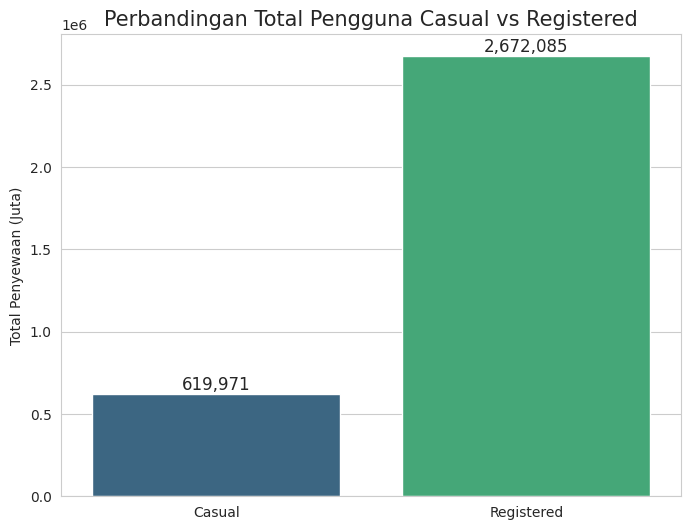

In [30]:
# Menghitung total untuk masing-masing tipe pengguna
total_casual = hour_df['casual'].sum()
total_registered = hour_df['registered'].sum()

# Membuat data untuk plotting
user_types = ['Casual', 'Registered']
total_counts = [total_casual, total_registered]

plt.figure(figsize=(8, 6))
sns.barplot(x=user_types, y=total_counts, palette="viridis", hue=user_types, legend=False)

plt.title("Perbandingan Total Pengguna Casual vs Registered", fontsize=15)
plt.ylabel("Total Penyewaan (Juta)")
# Memberikan label angka di atas bar
for i, count in enumerate(total_counts):
    plt.text(i, count, f'{count:,}', ha='center', va='bottom', fontsize=12)

plt.show()

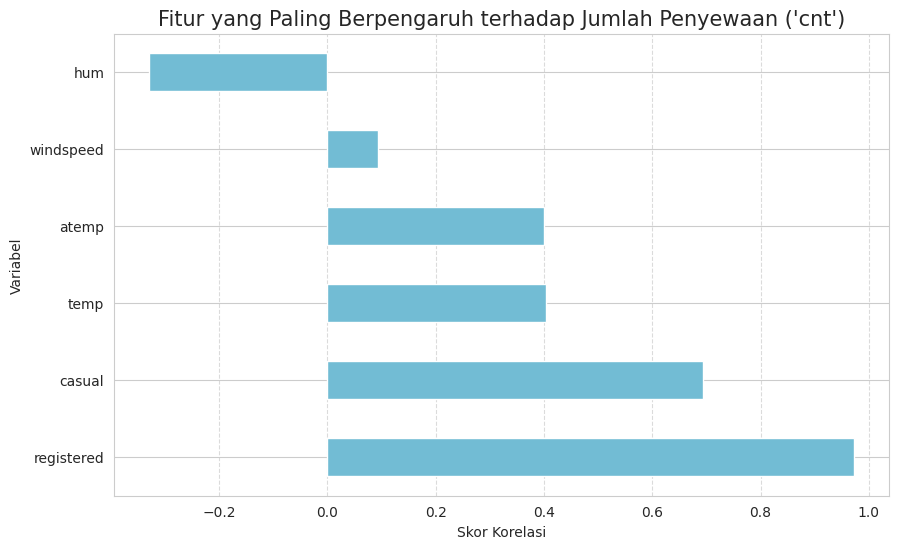

In [31]:
# menghitung korelasi terhadap kolom 'cnt' (jumlah penyewaan)
correlation_cols = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']
top_features = hour_df[correlation_cols].corr()['cnt'].sort_values(ascending=False).drop('cnt')

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh', color='#72BCD4')

plt.title("Fitur yang Paling Berpengaruh terhadap Jumlah Penyewaan ('cnt')", fontsize=15)
plt.xlabel("Skor Korelasi")
plt.ylabel("Variabel")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_8115/2942906557.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="season", y="cnt", data=hour_df, palette="rocket")


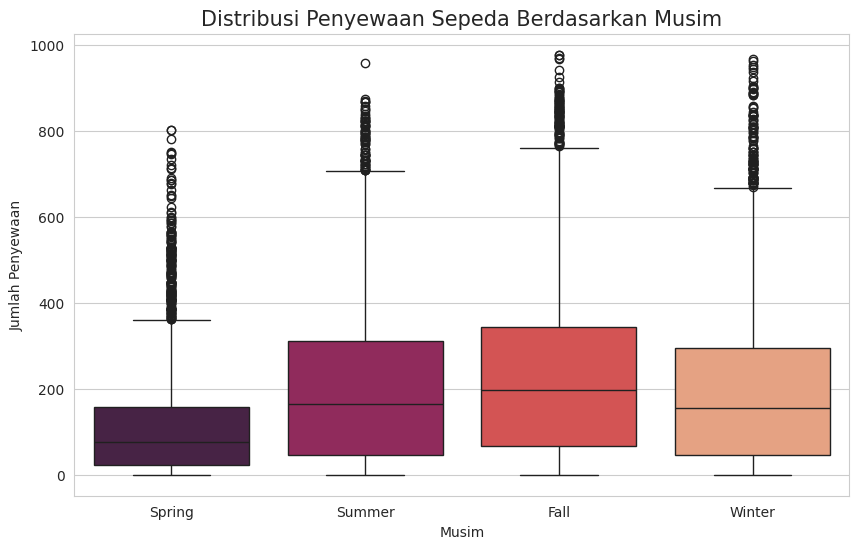

In [32]:
# boxplot untuk melihat outlier dalam distribusi data
plt.figure(figsize=(10, 6))
sns.boxplot(x="season", y="cnt", data=hour_df, palette="rocket")

plt.title("Distribusi Penyewaan Sepeda Berdasarkan Musim", fontsize=15)
plt.xlabel("Musim")
plt.ylabel("Jumlah Penyewaan")
plt.show()

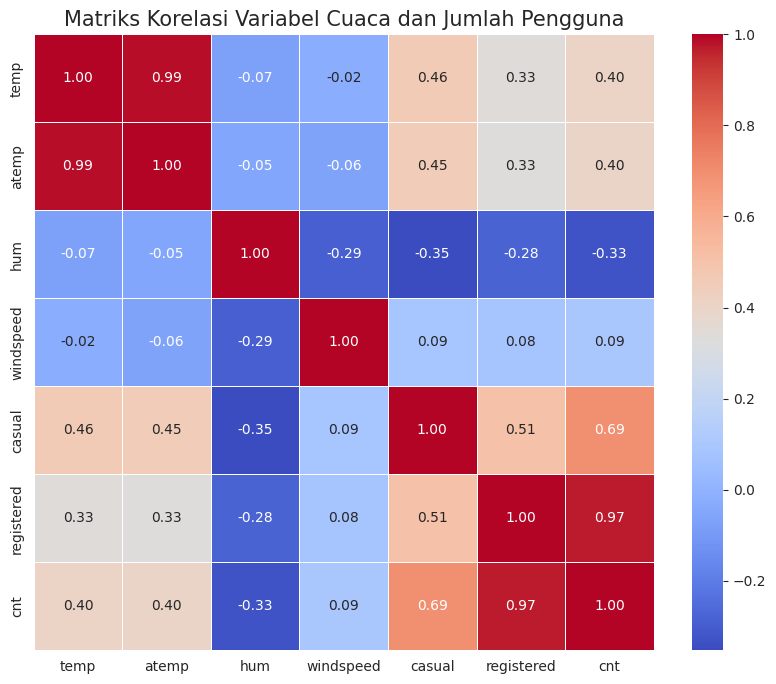

In [33]:
plt.figure(figsize=(10, 8))
# mengambil kolom numerik yang relevan
correlation_cols = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']
correlation_matrix = hour_df[correlation_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriks Korelasi Variabel Cuaca dan Jumlah Pengguna", fontsize=15)
plt.show()

**Insight Analisis Lanjutan:**

1. **Segmentasi Pengguna: Dominasi Loyalitas (Registered Users)**

* **Temuan Utama:** Terdapat perbedaan volume yang sangat kontras antara pengguna terdaftar (`Registered`) dan pengguna biasa `(Casual`). Pengguna terdaftar menyumbang **81,2% **dari total penyewaan (**2,67 juta** vs **0,62 juta**).

* **Insight Bisnis:** Bisnis ini sangat bergantung pada basis pelanggan setia. Strategi pemasaran jangka panjang harus difokuskan pada **program retensi member**, karena mereka adalah tulang punggung pendapatan perusahaan.

---

2. **Analisis Fitur Paling Berpengaruh**
- **Korelasi Suhu (Positif):** Berdasarkan matriks korelasi dan grafik kepentingan fitur, Suhu (`temp & atemp`) adalah faktor cuaca yang paling memengaruhi penyewaan (**Skor: 0,40**). Artinya, semakin hangat suhu (hingga titik nyaman tertentu), semakin tinggi keinginan orang untuk bersepeda.

- **Korelasi Kelembapan (Negatif):** Kelembapan (`hum`) memiliki korelasi negatif **(-0,33)**. Ini berarti udara yang terlalu lembap atau mendung/basah menjadi penghambat utama pengguna untuk menyewa sepeda.

- **Insight Teknis:** Variabel registered memiliki korelasi hampir sempurna **(0,97)** dengan total penyewaan (`cnt`), mengonfirmasi bahwa pertumbuhan total penyewaan hampir selalu sejalan dengan pertumbuhan jumlah member.

---

3. **Dinamika Musiman & Karakteristik Data (Seasonal Variability)**

- **Musim Gugur (Fall) sebagai Puncak:** Melalui grafik boxplot, terlihat bahwa musim gugur memiliki median penyewaan tertinggi dan rentang data yang lebih luas ke atas.

- **Analisis Outlier:** Terdapat banyak titik outlier (nilai ekstrem) di setiap musim, terutama pada musim panas (Summer) dan musim gugur. Hal ini membuktikan adanya lonjakan permintaan yang sangat tinggi pada momen-momen tertentu (misalnya: acara kota atau cuaca yang sangat ideal) yang melampaui rata-rata harian.

- **Insight Operasional:** Perusahaan perlu menyiapkan stok sepeda ekstra pada musim gugur dan musim panas untuk mengantisipasi lonjakan permintaan yang sering melampaui batas normal (titik-titik outlier tersebut).

## Conclusion & Recommendation

**Conclusion pertanyaan 1:**

Kondisi cuaca merupakan determinan utama dalam fluktuasi permintaan penyewaan sepeda. Berdasarkan analisis, cuaca Clear/Cerah menghasilkan performa tertinggi dengan rata-rata **204,87** penyewaan/jam, disusul oleh cuaca berkabut (*Misty*). Penurunan drastis terjadi pada kondisi hujan/salju ringan, dan mencapai titik terendah pada cuaca ekstrem. Secara statistik, variabel Suhu (`temp`) memiliki korelasi positif terkuat **(0,40)** terhadap jumlah pengguna, sementara kelembapan (`hum`) memiliki korelasi negatif yang menghambat minat bersepeda.

---

**Conclusion pertanyaan 2:**

Terdapat dikotomi perilaku pengguna yang sangat jelas antara hari kerja dan hari libur:

- **Hari Kerja:** Puncak penyewaan terkonsentrasi pada **Jam Sibuk (Rush Hour)**, yaitu pukul **08:00** dan **17:00 - 18:00**, yang mengindikasikan penggunaan sepeda sebagai moda transportasi utilitas untuk bekerja atau menempuh pendidikan.

- **Hari Libur/Akhir Pekan:** Puncak penyewaan bergeser menjadi pola **Lonceng Tunggal (Single Peak)** di siang hari, mencapai puncaknya pada pukul **13:00 (372,73 penyewaan/jam)**. Hal ini menunjukkan dominasi penggunaan sepeda untuk tujuan rekreasi dan gaya hidup.

**Rekomendasi Action Item:**

Berdasarkan temuan di atas, berikut adalah beberapa langkah nyata yang bisa direkomendasikan kepada tim operasional atau manajemen:

1. **Optimalisasi Inventori Musiman:** Mengingat bulan **Agustus** dan Musim **Gugur (Fall)** adalah periode puncak, perusahaan harus memastikan seluruh armada sepeda dalam kondisi prima dan tersedia maksimal pada periode tersebut untuk menangkap lonjakan permintaan (peak demand).

2. **Strategi Pemeliharaan (Maintenance) Terjadwal:**

   - Pada **Hari Kerja**, lakukan pengecekan rutin pada pukul **10:00 - 14:00** (saat permintaan menurun di antara dua puncak jam sibuk).

    - Pada **Hari Libur**, lakukan pemeliharaan di pagi hari (**sebelum pukul 09:00**) sebelum lonjakan rekreasi dimulai.

3. **Program Loyalitas & Segmentasi:** Mengingat Registered Users menyumbang lebih dari **80%** total volume, fokus utama harus tetap pada **program retensi member** (misal: diskon perpanjangan langganan). Namun, terdapat peluang besar untuk meningkatkan konversi pengguna Casual menjadi member dengan memberikan promo khusus di akhir pekan/siang hari.

3. **Manajemen Risiko Cuaca:** Karena kelembapan dan hujan menurunkan minat pengguna, perusahaan dapat mempertimbangkan fitur tambahan pada aplikasi seperti "Prediksi Ketersediaan Berbasis Cuaca" atau memberikan insentif/poin tambahan bagi pengguna yang tetap bersepeda saat kondisi cuaca kurang ideal (mendung).

In [37]:
# ekspor data frame hasil cleaning
hour_df.to_csv("main_data.csv", index=False)